# 01 — Keşifsel Veri Analizi (EDA)

**Amaç:** Telco Customer Churn verisini tanımak; boyut, tipler, eksik/bozuk değer, hedef (`Churn`) dağılımı ve sayısal–kategorik değişkenlerin churn ile ilişkisini görmek.

**Not:** Bu notebookta model eğitilmez. Bulgular proje `FINDINGS.md` dosyasıyla uyumludur. Ham dosya `data/WA_Fn-UseC_-Telco-Customer-Churn.xls` uzantılıdır; içerik CSV formatındadır, bu yüzden `pd.read_csv` kullanılır.

Aşağıda her kod hücresinden **önce** ne yapıldığı markdown ile açıklanır.

### Kütüphaneler (bir sonraki hücre)
`pandas` / `numpy` tablo ve sayı işleri; `matplotlib` ve `seaborn` grafik; `%matplotlib inline` grafiklerin notebook içinde gösterilmesi için.

In [1]:
# --- Kütüphaneler ve veri klasörü ---
# Dosya yolları için
from pathlib import Path

# Tablo ve sayı işlemleri
import pandas as pd
import numpy as np
# Grafik çizimi
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin notebook çıktısında gösterilmesi
%matplotlib inline


def _resolve_data_dir() -> Path:
    # Jupyter bazen proje kökünde, bazen notebooks/ klasöründe çalışır; ham CSV yolunu bul
    for rel in (Path('data'), Path('../data')):
        # Olası göreli yolu mutlak yola çevir ve dosya var mı bak
        candidate = (rel / 'WA_Fn-UseC_-Telco-Customer-Churn.xls').resolve()
        if candidate.is_file():
            # Dosyanın bulunduğu klasörü (data/) döndür
            return candidate.parent
    raise FileNotFoundError("Ham veri dosyası bulunamadı (data/ veya ../data/).")


# Tüm okuma işlemleri bu klasörü kullanacak
DATA = _resolve_data_dir()


### Veriyi yükleme (bir sonraki hücre)
Kaggle Telco churn verisi okunur. İlk satırlar `head()` ile kontrol edilir: sütun isimleri, `Churn` hedefi, kategorik metin alanlar.

In [2]:
# --- Veriyi yükle ---
# Ham veriyi CSV olarak oku (uzantı .xls ama içerik virgülle ayrılmış)
df = pd.read_csv(DATA / "WA_Fn-UseC_-Telco-Customer-Churn.xls")
# İlk 5 satırı tablo olarak göster
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Boyut, sütunlar, tipler, eksik değer (bir sonraki hücre)
- **Boyut:** kaç müşteri (satır), kaç değişken (sütun).
- **dtypes:** `TotalCharges` çoğu zaman `object` çıkar; ön işlemede sayısala çevrilecek.
- **isnull:** Kaggle setinde genelde 0; `TotalCharges` içinde boşluk gibi gizli sorunlar ayrı hücrede incelenir.

In [3]:
# --- Boyut, tipler, eksik değer ---
# Satır ve sütun sayısı
print("Boyut:", df.shape)
# Tüm sütun adlarını liste olarak yazdır
print("\nSütunlar:\n", df.columns.tolist())
# Her sütunun pandas veri tipi
print("\nVeri Tipleri:\n", df.dtypes)
# isnull: eksik (NaN) hücre sayısı sütun bazında
print("\nEksik Değerler (isnull):\n", df.isnull().sum())


Boyut: (7043, 21)

Sütunlar:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Veri Tipleri:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Eksik Değerler (isnull):
 c

### Sayısal özet — `describe` (bir sonraki hücre)
Ham tabloda `TotalCharges` string olduğu için `df.describe()` bu sütunu atlayabilirdi. Burada **geçici** `to_numeric` ile bir özet DataFrame oluşturulur; **orijinal `df` değiştirilmez**. Ön işleme notebook’unda aynı sütun kalıcı dönüştürülür.

In [4]:
# --- Sayısal özet (describe) ---
# Sayısal özet için kopya tablo; orijinal df’e dokunma
num_summary = df[["SeniorCitizen", "tenure", "MonthlyCharges"]].copy()
# TotalCharges metin olabilir; sayıya çevir, olmayanları NaN yap (coerce)
num_summary["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# count, mean, std, min, çeyrekler, max
num_summary.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### Hedef değişken `Churn` (bir sonraki hücre)
Kaç `Yes` / `No`, yüzde dağılım ve çubuk grafik. Oran ~%26–27 tipiktir; veri **dengesiz** — modelde yalnızca accuracy yeterli değildir.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Oran:
 Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


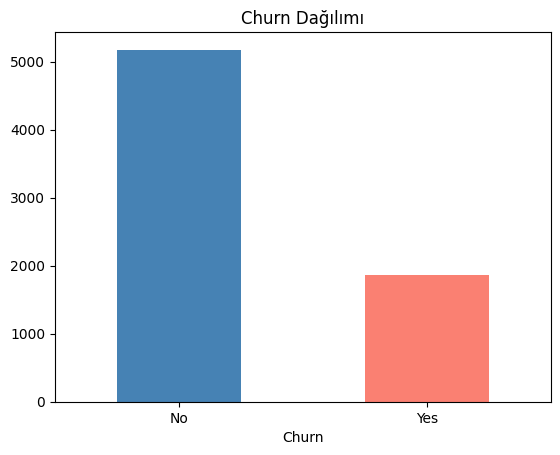

In [5]:
# --- Hedef Churn dağılımı ---
# Yes/No mutlak frekansları
print(df['Churn'].value_counts())
# Sınıf oranları (toplam 1 olacak şekilde); 3 ondalık
print("\nOran:\n", df['Churn'].value_counts(normalize=True).round(3))

# Frekansları çubuk grafikle göster
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
# Grafik başlığı
plt.title('Churn Dağılımı')
# x ekseni etiketlerini yatay tut
plt.xticks(rotation=0)
# Grafiği ekrana bas
plt.show()


### `TotalCharges` tip ve örnek değerler (bir sonraki hücre)
Sütunun `object` olması ve ham `unique` değerler ön işleme stratejisini doğrular.

In [6]:
# --- TotalCharges ham inceleme ---
# pandas’ın bu sütun için gördüğü tip (çoğunlukla object/str)
print(df["TotalCharges"].dtype)
# İlk 20 benzersiz ham değer (boşluk vb. görmek için)
print(df["TotalCharges"].unique()[:20])


str
<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str


### Sayısal değişken histogramları (bir sonraki hücre)
`tenure`, `MonthlyCharges`, `TotalCharges` dağılımları. `TotalCharges` çizim için geçici sayısallaştırılır.

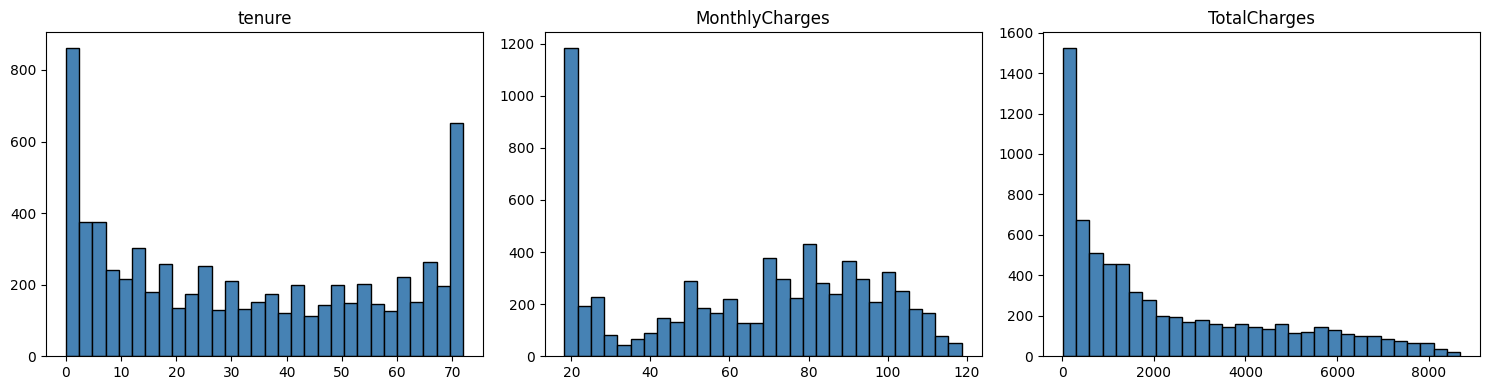

In [7]:
# --- Sayısal histogramlar ---
# 1 satır 3 sütun alt grafik; geniş figür
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Üç sayısal sütun için döngü
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    # TotalCharges için geçici sayı dönüşümü
    temp = pd.to_numeric(df[col], errors='coerce')
    # Histogram: dağılım
    axes[i].hist(temp, bins=30, color='steelblue', edgecolor='black')
    # Alt grafik başlığı = sütun adı
    axes[i].set_title(col)
# Alt grafikler arası boşluğu sıkılaştır
plt.tight_layout()
plt.show()


### Churn’e göre kutu grafikleri (bir sonraki hücre)
Kalan vs ayrılan müşterilerde sayısal değişkenlerin medyan ve yayılımı.

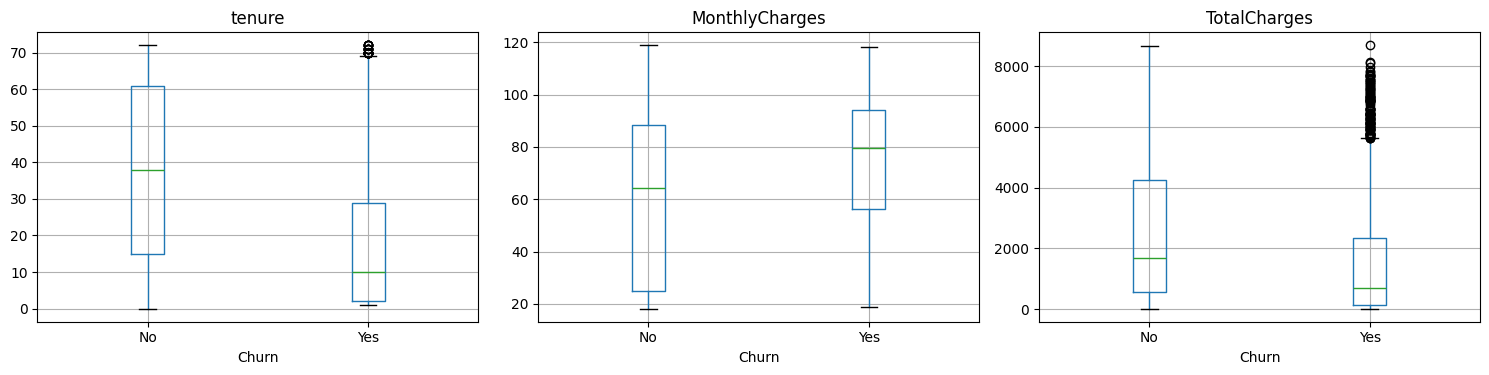

In [8]:
# --- Churn’e göre boxplot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    # boxplot df’i değiştirmesin diye kopya
    temp_df = df.copy()
    # İlgili sütunu sayısal yap
    temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
    # Churn gruplarına göre kutu grafiği
    temp_df.boxplot(column=col, by='Churn', ax=axes[i])
    axes[i].set_title(col)
# pandas’ın eklediği genel üst başlığı kaldır
plt.suptitle('')
plt.tight_layout()
plt.show()


### Seçili kategoriklerde churn oranı (bir sonraki hücre)
Sözleşme, internet, ödeme, teknik destek, online güvenlik gruplarında `Churn == Yes` oranı.

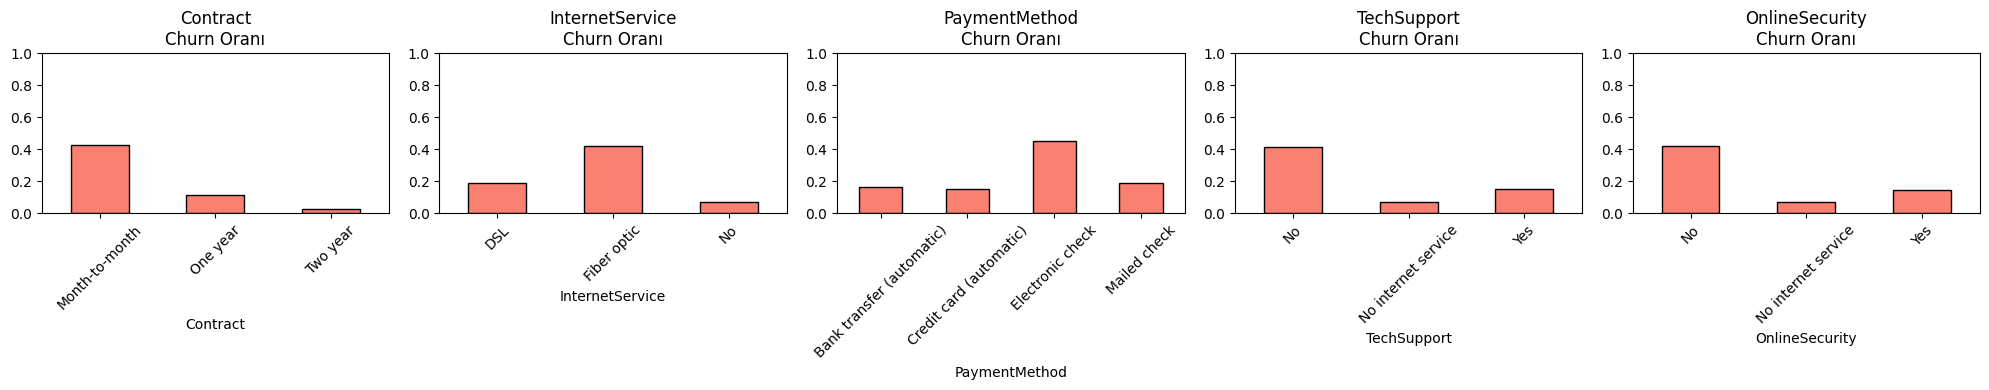

In [9]:
# --- Kategorik churn oranları ---
# Churn oranına bakılacak kategorik sütunlar
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']

# Her kategori için bir alt grafik
fig, axes = plt.subplots(1, len(cat_cols), figsize=(20, 4))
for i, col in enumerate(cat_cols):
    # Her kategori değeri için Churn=Yes oranı
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    churn_rate.plot(kind='bar', ax=axes[i], color='salmon', edgecolor='black')
    axes[i].set_title(f'{col}\nChurn Oranı')
    # Oran 0–1 aralığında kalsın
    axes[i].set_ylim(0, 1)
    # Uzun etiketler okunaklı olsun
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## EDA özeti (kısa)

1. **7043** müşteri, **21** sütun; hedef **Churn** (Yes/No).
2. Churn oranı ~**%26.5** — sınıflar dengesiz; recall / F1 / ROC-AUC önemli.
3. **TotalCharges** metin tipinde; ön işlemede sayısala çevrilir ve eksikler doldurulur.
4. **customerID** modele sokulmamalı.
5. Sonraki adımlar: `notebooks/02_preprocessing.ipynb` → `data/processed/train_test_split.pkl` → `03_modeling.ipynb`.